# GV Exercise – Modular Pipeline Notebook

This notebook demonstrates the exact same data preparation, training, and inference flow as the production code by importing the reusable modules under `src/`.

It intentionally avoids ad-hoc pandas logic so experiments stay aligned with the CLI scripts and MLflow-tracked runs.

In [1]:
%pip install seaborn
%pip install optuna
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Phase 1: Environment Setup

Bootstrap project imports and configuration. This sets up the shared imports, config, and logging so experiments match CLI runs.

In [2]:
import sys
import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import xgboost as xgb

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.common import load_config
from src.common.logging import init_logging
from src.models.io import load_model_bundle
from src.predict.inference import predict_batch
from src.models.training import train_ranker
from src.models.training_pipeline import build_training_dataset
from src.features.pipeline import FeaturePipeline

cfg = load_config()
init_logging(cfg.logging)
cfg


Config(project=ProjectConfig(root=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost')), data=DataConfig(raw_dir=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/data/real'), curated_dir=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/data/training'), training_file=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/data/training/target_variable_training.csv'), schema_version='v1', ranking_files=RankingFiles(founder_experience='founder_experience.csv', education='education.csv', company_info='company_info.csv'), training_files=TrainingFiles(founder_experience='founder_experience_training.csv', education='education_training.csv', company_info='company_info_training.csv')), features=FeatureConfig(registry=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/data/features'), current_year=2025, selected_columns=['performance', 'education_tier', 'education_level_score', 'founder_has_perf', 'founder_perf_mean', 'founder_perf_max'

## Phase 2: Data Loading & Feature Engineering

Build the training dataset directly from packaged loaders. This pulls packaged training data and cleans it with the same helpers used in production. It also performs manual feature engineering and builds the feature matrix.

### 2.1 Data Loading & Cleaning

Load the raw training data and target labels from the configured data directories.

In [3]:
from src.data.loaders import load_raw, clean, load_targets
raw_training = load_raw(cfg.data, dataset='training')
clean_training = clean(raw_training)
raw_ranking = load_raw(cfg.data, dataset='ranking')
clean_ranking = clean(raw_ranking)
target_df = load_targets(cfg.data)
print('Training:', { 'experience': clean_training.experience.shape, 'education': clean_training.education.shape, 'company_info': clean_training.company_info.shape })
print('Ranking:', { 'experience': clean_ranking.experience.shape, 'education': clean_ranking.education.shape, 'company_info': clean_ranking.company_info.shape })
print('Targets:', target_df.shape, list(target_df.columns))


Training: {'experience': (54616, 12), 'education': (4772, 3), 'company_info': (13898, 3)}
Ranking: {'experience': (1583, 12), 'education': (120, 3), 'company_info': (456, 3)}
Targets: (2000, 4) ['company_id', 'industry', 'company_founded', 'multiple']


### 2.5 Feature Matrix Construction

Build the feature matrix from the clean training data using the initialized pipeline.

In [4]:
training_df = build_training_dataset(clean_training, clean_ranking, target_df, cfg.features)

### 2.7 Manual Feature Engineering

Apply any manual feature engineering steps, such as handling missing values or creating custom flags, and define the final list of feature columns.

In [5]:
# Define feature columns from config
feature_columns = cfg.features.selected_columns

## Phase 3: Data Splitting

Perform per-industry cohort splitting with temporal ordering. We split the data by industry and use temporal ordering (older companies in train, newer in test) to simulate a realistic production scenario.

In [6]:
from src.data.splitters import split_by_industry

# Split by industry with temporal ordering (older companies in train, newer in test)
X_train, y_train, X_test, y_test, train_df, test_df, train_groups, test_groups, industry_names = split_by_industry(
    df=training_df,
    feature_cols=feature_columns,
    target_col=cfg.features.target_column,
    train_ratio=0.8
)

print(f"\nTraining rows: {len(training_df)} | Feature columns: {len(feature_columns)}")
training_df.head()


=== Split Summary ===
Total samples: 4763
Train samples: 3809 (80.0%)
Test samples: 954 (20.0%)
Number of industry cohorts: 3

Train groups (per industry): [814, 2348, 647]
Test groups (per industry): [204, 588, 162]

=== Per-Industry Breakdown ===

Healthcare and Biotech:
  Total: 1018 | Train: 814 (80.0%) | Test: 204 (20.0%)
  Train labels: {0: 374, 1: 228, 2: 114, 3: 75, 4: 16, 6: 7}
  Test labels: {0: 173, 1: 23, 2: 4, 3: 4}

Information Technology:
  Total: 2936 | Train: 2348 (80.0%) | Test: 588 (20.0%)
  Train labels: {0: 1349, 1: 406, 2: 289, 3: 206, 4: 76, 5: 12, 6: 10}
  Test labels: {0: 544, 1: 21, 2: 14, 3: 2, 4: 4, 5: 3}

Other:
  Total: 809 | Train: 647 (80.0%) | Test: 162 (20.0%)
  Train labels: {0: 443, 1: 63, 2: 47, 3: 29, 4: 16, 5: 41, 6: 5, 7: 3}
  Test labels: {0: 159, 2: 3}

Training rows: 4763 | Feature columns: 7


,person_id,company_id,performance,education_tier,education_level_score,founder_has_perf,founder_perf_mean,founder_perf_max,founder_perf_last,industry,is_founder_of_target,company_founded,label
0,SAZwAA4FHAkwCwkOFTQdDwwAGg==,SBVwFg0CFhgOFA==,0.203511,4.0,3.0,1,0.203511,0.203511,0.203511,Information Technology,True,2014.0,0
1,SAZwAA4FHDcFDAgIAyw=,SBVwGgQTCAc=,10.000000,4.0,3.0,1,10.000000,10.000000,10.000000,Information Technology,True,2010.0,3
2,SAZwAA4FHDcJCBcJFzEQBBg6WF9c,SBVwGgQfFgsOHQA=,10.000000,5.0,1.0,1,10.000000,10.000000,10.000000,Information Technology,True,1993.0,4
3,SAZwAA4FHDcJDBAUAjYaCA==,SBVwGAgMDRwCBAsCBAAHGBgRDQIe,0.754910,4.0,3.0,1,0.754910,0.754910,0.754910,Information Technology,True,2012.0,0
4,SAZwAA4FHDcMFwQVGDYf,SBVwHQ0HEAUGAwQ=,10.000000,5.0,4.0,1,10.000000,10.000000,10.000000,Healthcare and Biotech,True,1998.0,3


## Phase 4: Data Validation

Quickly verify data integrity by checking for any records with the default '2025' year, which would indicate missing founded dates.

In [7]:
(training_df['company_founded'] == 2025).sum()

np.int64(0)

## Phase 5: Model Training

Train the XGBoost ranker using config-driven hyperparameters. This ensures the training process in the notebook mirrors the production pipeline.

In [8]:
params = cfg.model.hyperparameters.copy()

ranker, metrics = train_ranker(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    train_groups=train_groups,
    test_groups=test_groups,
    industry_names=industry_names,
    params=params,
    tracking_uri=cfg.tracking.uri,
    experiment_name=cfg.tracking.experiment_name,
    run_name=datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
)

/Users/yugu/Desktop/gehirn/gv_case_study/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/11/24 12:41:12 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2025/11/24 12:41:12 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2025/11/24 12:41:12 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: ndcg_at_20
2025/11/24 12:41:12 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have bee


=== Per-Industry NDCG@20 Scores ===
Healthcare and Biotech:
  Train: 0.2067 | Test: 0.4175
Information Technology:
  Train: 0.2605 | Test: 0.6553
Other:
  Train: 0.3795 | Test: 0.4967

=== Mean NDCG@20 ===
Train ndcg@20: 0.2822
Test ndcg@20: 0.5232


## Phase 6: Model Persistence

Persist artifacts alongside metadata, identical to the CLI script. This saves the trained model and auxiliary metadata (like feature columns and outcome lookups) to the artifacts directory.

In [9]:
# Persist the trained bundle locally to mirror CLI artifact structure
run_name = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
# Organize notebook runs under timestamped folders for traceability
run_dir = cfg.model.artifact_dir / "notebook_runs" / run_name
run_dir.mkdir(parents=True, exist_ok=True)

model_path = run_dir / "ranker.json"
artifacts_path = run_dir / "artifacts.json"
# Save the booster for reuse in inference cells
ranker.save_model(model_path)

# Bundle auxiliary metadata used during inference
artifacts = {
    "feature_columns": feature_columns,
}
# Persist metadata next to the model bundle
artifacts_path.write_text(json.dumps(artifacts, indent=2))

run_dir


PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/mlruns/models/notebook_runs/20251124T174116Z')

## Phase 7: Inference

Load the freshly written bundle and score current founders. This demonstrates how to reload the saved model and use it to generate predictions for new data.

**Note on SHAP Explanations:**
We enable SHAP value calculation (`shap_top_n=3`) to provide local interpretability for each prediction. The `explanation` column in the output dataframe lists the top 3 features contributing to the score for each founder.

In [10]:
# Reload the saved bundle and score the latest founders
bundle = load_model_bundle(
    registry_cfg=cfg.registry,
    project_root=cfg.project.root,
    model_root=run_dir,
)

# Pull current founders and clean them the same way as training data
raw_ranking = load_raw(cfg.data, dataset="ranking")
clean_ranking = clean(raw_ranking)

# Build the feature matrix for ranking founders using the same feature config
feature_pipeline = FeaturePipeline(cfg.features)
ranking_features = feature_pipeline.build_matrix(clean_ranking)

# Run batch prediction with SHAP explanations enabled (top 3 features)
predictions = predict_batch(bundle, ranking_features, shap_top_n=3)
predictions.head()


,founder_id,industry,score,rank,explanation
0,SAZwFRMGAAYwHgQAHj4ABAcMCQE=,Information Technology,-0.501923,1,"Top factors: performance (-0.68), education_ti..."
1,SAZwAAgMFwkBMgsGDD4GGAoLNx8FOgM=,Information Technology,-0.656837,2,"Top factors: performance (-0.74), education_ti..."
2,SAZwBwQZAg0WMggGBDQbEhIEBg==,Information Technology,-0.944078,3,"Top factors: performance (-0.69), education_ti..."
3,SAZwDgAAOgsAAQA=,Information Technology,-1.144019,4,"Top factors: performance (-0.80), founder_perf..."
4,SAZwGAQKDTccBAcCGDoG,Healthcare and Biotech,-1.363123,5,"Top factors: performance (-1.10), education_ti..."


## Phase 8: Ranking Explanation

Visualize the feature importance and impact using SHAP (SHapley Additive exPlanations). This provides a global view of what drives the model's ranking decisions.

SHAP Summary Plot (Global Feature Importance):


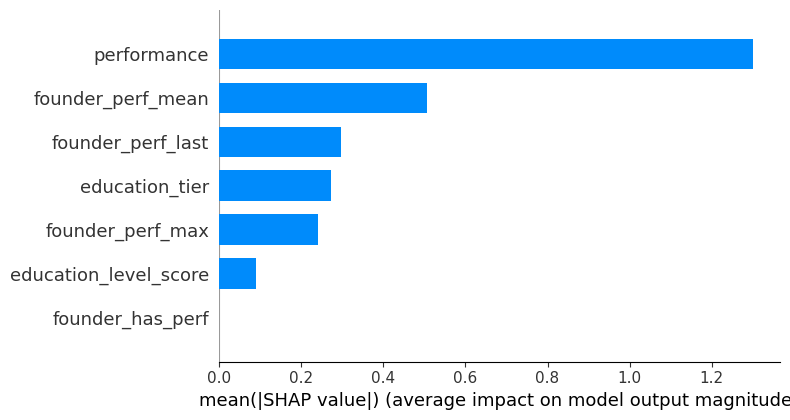

SHAP Beeswarm Plot (Feature Impact Direction):


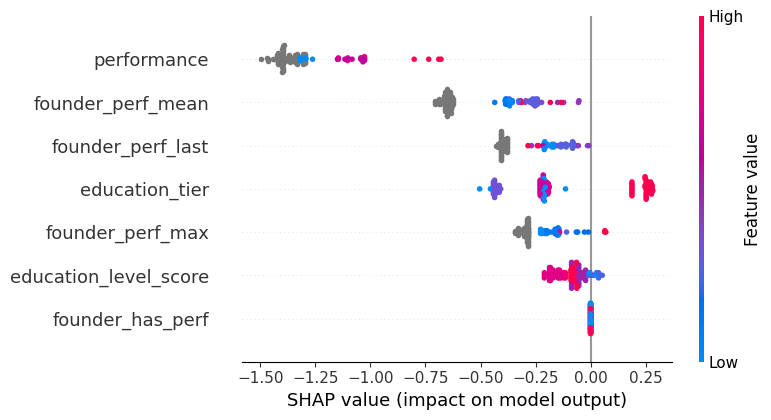


SHAP summary for industry: Healthcare and Biotech (n=13)


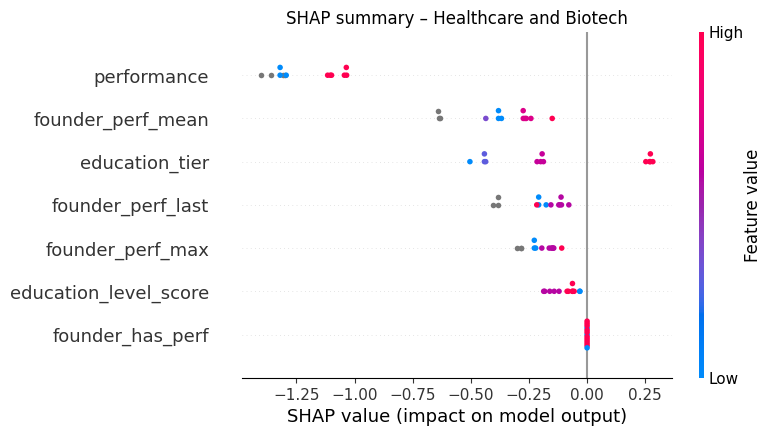


SHAP summary for industry: Information Technology (n=75)


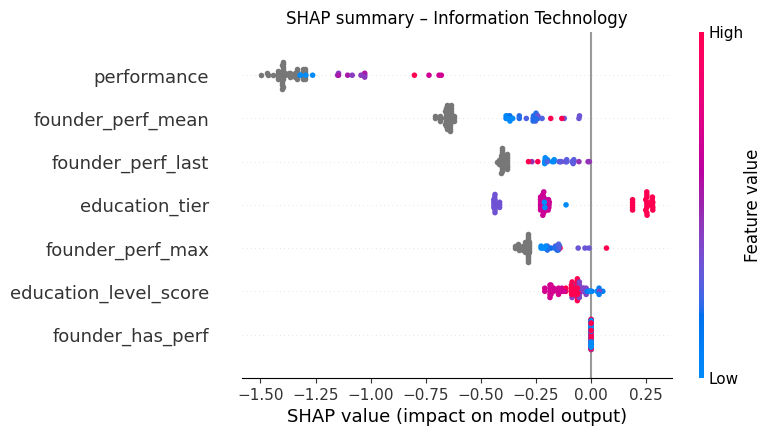


SHAP summary for industry: Other (n=27)


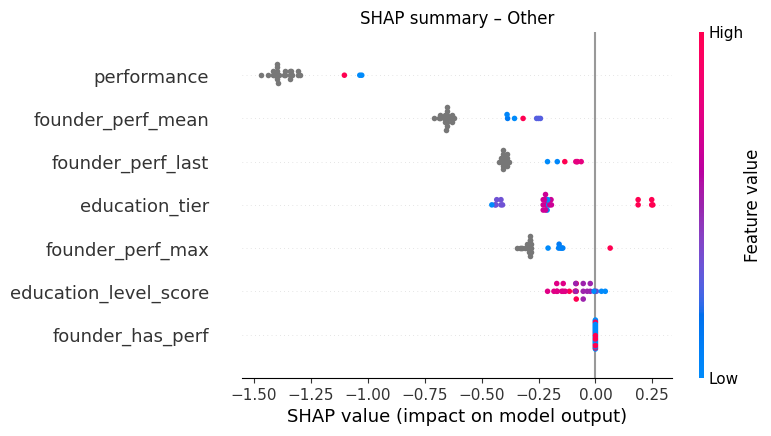

In [11]:
import shap
import matplotlib.pyplot as plt

# Use the estimator from the loaded bundle
model = bundle.estimator

# Select only the feature columns for SHAP calculation
X_ranking = ranking_features.select_columns(bundle.feature_columns)

# Initialize the explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ranking)

# Handle case where shap_values might be a list (for some XGBoost objectives)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

print("SHAP Summary Plot (Global Feature Importance):")
shap.summary_plot(shap_values, X_ranking, plot_type="bar")
plt.show()

print("SHAP Beeswarm Plot (Feature Impact Direction):")
shap.summary_plot(shap_values, X_ranking)
plt.show()

# Per-industry SHAP summary (excluding unknown)
industry_series = ranking_features.frame["industry"]
valid_industries = [
    value
    for value in sorted(industry_series.dropna().unique())
    if isinstance(value, str) and value and value.lower() != "unknown"
]

for industry in valid_industries:
    mask = industry_series == industry
    print(f"\nSHAP summary for industry: {industry} (n={mask.sum()})")
    shap.summary_plot(
        shap_values[mask.values],
        X_ranking[mask.values],
        show=False,
    )
    plt.title(f"SHAP summary – {industry}")
    plt.show()


> **Why does `artifacts.json` store company outcomes?**
>
> The mapping is used to label past companies when computing founder experience features (e.g., counting prior 10x exits). Each founder example still receives an individual label during training (`relevance_grade`) and we score founders after training, but we need company-level multiples to quantify their historical track records.

In [12]:
predictions

,founder_id,industry,score,rank,explanation
0,SAZwFRMGAAYwHgQAHj4ABAcMCQE=,Information Technology,-0.501923,1,"Top factors: performance (-0.68), education_ti..."
1,SAZwAAgMFwkBMgsGDD4GGAoLNx8FOgM=,Information Technology,-0.656837,2,"Top factors: performance (-0.74), education_ti..."
2,SAZwBwQZAg0WMggGBDQbEhIEBg==,Information Technology,-0.944078,3,"Top factors: performance (-0.69), education_ti..."
3,SAZwDgAAOgsAAQA=,Information Technology,-1.144019,4,"Top factors: performance (-0.80), founder_perf..."
4,SAZwGAQKDTccBAcCGDoG,Healthcare and Biotech,-1.363123,5,"Top factors: performance (-1.10), education_ti..."
...,...,...,...,...,...
115,SAZwGQAfEQAGDBY4HjASDAoLBjAdDTgS,Healthcare and Biotech,-3.167706,51,"Top factors: performance (-1.30), founder_perf..."
116,SAZwDQ4FAgIGAzoXFy0f,Information Technology,-3.167706,51,"Top factors: performance (-1.30), founder_perf..."
117,SAZwBg4FOgoKHwsUAjodDw==,Information Technology,-3.167706,51,"Top factors: performance (-1.30), founder_perf..."
118,SAZwHg4YADcCDAsSEzMrFwIJBA4DEAIAPg==,Information Technology,-3.167706,51,"Top factors: performance (-1.30), founder_perf..."
